In [10]:
import os
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMAGE_SIZE = 128  
BATCH_SIZE = 32   

# rescaling
datagen = ImageDataGenerator(rescale=1./255)

train_df = pd.read_csv('augmented_data.csv')  
train_df['image_path'] = train_df['id_code'].apply(lambda x: os.path.join('training', f"{x}"))  
train_df['diagnosis'] = train_df['diagnosis'].astype(str)


val_df = pd.read_csv('validation.csv')  # Load your validation dataframe file
val_df['image_path'] = val_df['id_code'].apply(lambda x: os.path.join('validation', f"{x}"))  #
val_df['diagnosis'] = val_df['diagnosis'].astype(str)

# Create the training generator
train_generator = datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=None,  
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical', 
    validate_filenames=False  
)

# Create the validation generator
val_generator = datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=None, 
    x_col='image_path',  
    y_col='diagnosis',
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',  
    shuffle=False,  
    validate_filenames=False  
)


Found 5000 non-validated image filenames belonging to 5 classes.
Found 1000 non-validated image filenames belonging to 5 classes.


In [12]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
import numpy as np
K=5

# Load VGG16 model 
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Extract features for training set
train_features = feature_extractor.predict(train_generator)
train_features = train_features.reshape(train_features.shape[0], -1)  # Flatten for KNN input

# Extract features for validation set
val_features = feature_extractor.predict(val_generator)
val_features = val_features.reshape(val_features.shape[0], -1)  # Flatten for KNN input

# Get the labels
y_train = train_generator.classes
y_val = val_generator.classes

# Train the KNN classifier
knn_model = KNeighborsClassifier(n_neighbors=K)
knn_model.fit(train_features, y_train)

# Predict on the validation set
y_pred = knn_model.predict(val_features)

# Classification report
class_labels = list(train_generator.class_indices.keys())
report = classification_report(y_val, y_pred, target_names=class_labels)
print(report)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")


C:\Users\Hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


150/150 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       502
           1       0.58      0.73      0.65       101
           2       0.77      0.71      0.74       267
           3       0.93      0.80      0.86        51
           4       0.81      0.78      0.79        79

    accuracy                           0.85      1000
   macro avg       0.81      0.80      0.80      1000
weighted avg       0.85      0.85      0.85      1000

Overall Accuracy: 0.8470
Overall Precision: 0.8524
Overall Recall: 0.8470


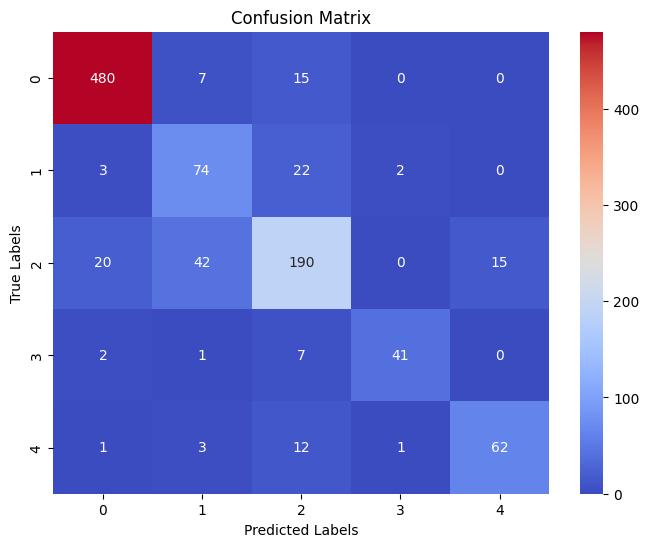

In [14]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()


In [15]:
#svm

from sklearn.svm import SVC

# Load VGG16 model 
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3))
feature_extractor = Model(inputs=base_model.input, outputs=base_model.output)

# Extract features for training set
train_features = feature_extractor.predict(train_generator)
train_features = train_features.reshape(train_features.shape[0], -1)  # Flatten for SVM input

# Extract features for validation set
val_features = feature_extractor.predict(val_generator)
val_features = val_features.reshape(val_features.shape[0], -1)  # Flatten for SVM input

# Get the labels
y_train = train_generator.classes
y_val = val_generator.classes

# Train the SVM classifier
svm_model = SVC(kernel='linear', probability=True)
svm_model.fit(train_features, y_train)

# Predict on the validation set
y_pred = svm_model.predict(val_features)

# classification report
class_labels = list(train_generator.class_indices.keys())
report = classification_report(y_val, y_pred, target_names=class_labels)
print(report)

accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, average='weighted')
recall = recall_score(y_val, y_pred, average='weighted')

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Overall Precision: {precision:.4f}")
print(f"Overall Recall: {recall:.4f}")


150/150 ━━━━━━━━━━━━━━━━━━━━ 288s 2s/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step
              precision    recall  f1-score   support

           0       0.97      0.94      0.95       502
           1       0.65      0.79      0.71       101
           2       0.83      0.73      0.78       267
           3       0.73      0.86      0.79        51
           4       0.71      0.85      0.77        79

    accuracy                           0.86      1000
   macro avg       0.78      0.84      0.80      1000
weighted avg       0.87      0.86      0.86      1000

Overall Accuracy: 0.8580
Overall Precision: 0.8671
Overall Recall: 0.8580


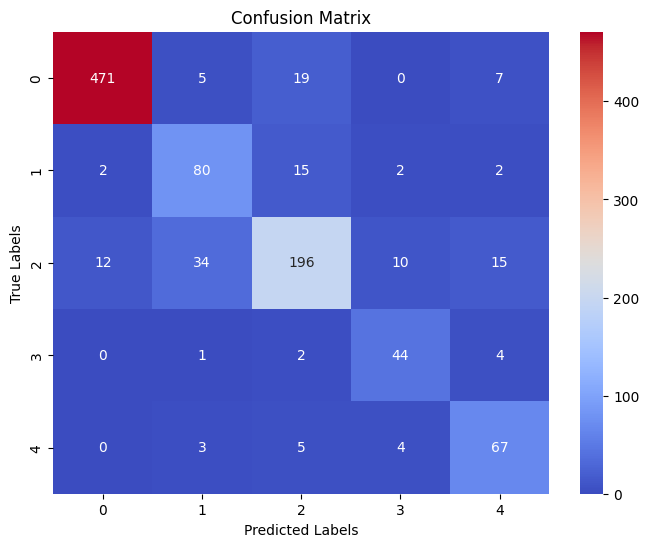

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

conf_matrix = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()
